# T32 — Macrostrat (https://macrostrat.org/) sedimentary units in paleo-position: mapping the Great Unconformity

**Pull every sedimentary unit overlying the Great Unconformity from the Macrostrat API, reconstruct each unit's outcrop location to its mid-formation age, and plot in paleo-position over the Great Unconformity formation window (~540 Ma in Laurentia). Adapted from Dhungana & Flament's online supplement to *The Deep Earth Origin of the Great Unconformity*.**

## What this notebook produces

Macrostrat (macrostrat.org) is the community geological database of formation-resolution stratigraphy — at the time of writing, more than 35,000 named units with location, basal/top age, and rock-type classification. This notebook calls the Macrostrat REST API, downloads the sedimentary units that formed during the Sauk and Tippecanoe transgressions (i.e. those overlying the Great Unconformity in Laurentia), reconstructs each unit's modern outcrop location to its mid-formation age using `gplately`, and plots the result on a single paleo-Earth map.

The figure makes a fundamentally different point from a present-day Macrostrat map: it lets you see WHERE on the contemporaneous Earth those rocks were when they formed, which is the only frame in which their tectonic and climatic context makes sense.

**Audience**: undergrad → postgrad.
**Difficulty**: ★★☆.

## Learning objectives

- Query a public geosciences REST API (Macrostrat) for a parameterised set of geological units.
- Reconstruct a list of (lon, lat, age) points to their paleo-positions with `gplately`.
- Plot a paleo-distribution of geological units on a single pyGMT map, colour-coded by formation age.
- Reason about the Great Unconformity in the frame in which it makes geological sense — i.e. with Laurentia in its 540 Ma position, not its 0 Ma position.

## Prerequisites and runtime

- Plate model: Cao 2024 (deep-time coverage).
- API: Macrostrat (https://macrostrat.org/api/). Free, no key, JSON response.
- Python: `gplately`, `pygmt`, `pygplates`, `requests`, `pandas`.
- Runtime: ~30 s end-to-end (API call dominates).

## Data availability — how to get the bundled netCDFs

This notebook reads time-dependent mantle / dynamic-topography
netCDFs from Santosh Dhungana's online supplement to
**Dhungana & Flament (2025) (https://github.com/santosh-dhungana/Dynamic-Topography-and-Great-Unconformity) — *The Deep Earth Origin of the Great
Unconformity***, soon to appear in *Journal of Geophysical Research —
Solid Earth*. The dataset is hosted in his GitHub repository, which
uses Git LFS for the binary files:

> https://github.com/santosh-dhungana/Dynamic-Topography-and-Great-Unconformity

The fields used by this notebook are too large to bundle into the
tutorial suite (multi-100 MB per cube, with sibling files totalling
GB-scale). To run T32 end-to-end, clone Santosh's repo (https://github.com/santosh-dhungana/Dynamic-Topography-and-Great-Unconformity)
with Git LFS:

```bash
# one-time install (macOS: brew install git-lfs; Linux: apt install git-lfs)
git lfs install

# then clone normally — LFS pull is automatic
git clone https://github.com/santosh-dhungana/Dynamic-Topography-and-Great-Unconformity
```

then set `SANTOSH_REPO` in the CONFIGURATION cell below to the local
path of your clone. The specific files this notebook reads are listed
in the cell after configuration, so you can confirm they exist before
running the rest of the workflow:


- `macrostrat_ProtoCamb.geojson` (~1 MB, sits in the repo root) — filter for Proto-Cambrian
  sedimentary units, used to seed the Macrostrat (https://macrostrat.org/) API call
- Macrostrat API itself does not need any bundled file; it's pulled at runtime from
  https://macrostrat.org/api/units


## Upstream data citations

- **Mantle-flow simulations** used by Dhungana & Flament rest on Müller
  et al.'s (2022) tectonic-rules-based mantle reference frame:
  https://doi.org/10.5194/se-13-1127-2022
- **Deep-time plate kinematics** used by the M2020 / Merdith
  reconstructions are from Merdith et al. (2021):
  https://doi.org/10.1016/j.earscirev.2020.103477
- **Late-Precambrian to Phanerozoic boundary kinematics** used by Cao
  2024 are from Cao et al. (2024): https://doi.org/10.5194/essd-16-4007-2024

When you publish a result derived from this notebook, please cite the
Dhungana & Flament (2025) paper for the dataset, the upstream Müller /
Merdith / Cao paper for whichever rotation model you used, and the
GPlately + pyGMT papers (Mather et al.  (https://github.com/brmather/SeafloorAnomalies)2024; Tian et al. 2024)
for the software stack.

In [6]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports
import numpy as np, pandas as pd
import requests
import gplately, pygmt, pygplates
from plate_model_manager import PlateModelManager
from pathlib import Path
from IPython.display import display, HTML
# Library versions (printed for reproducibility)
try:
    import gplately, pygmt, pygplates
    print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")


gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration — change the age window + paleo-target time here

In [7]:
# === USER CONFIGURATION =====================================================
MODEL_NAME    = "Cao2024"
AGE_RANGE_MA  = (472.0, 635.0)    # Sauk + Tippecanoe transgressions (Laurentia)
TARGET_TIME   = 540.0             # Ma — plot all units in their 540 Ma frame
LITHOLOGY_KEY = "sedimentary"     # Macrostrat lithology filter
# 
# --- Santosh's data root (see Data availability cell above) ---
import os
from pathlib import Path
# === SANTOSH_REPO — point this at your local clone =========================
SANTOSH_REPO = os.environ.get(
    "SANTOSH_REPO",
    str(Path("./external/Dynamic-Topography-and-Great-Unconformity")),
)
# ============================================================================


## 1. Pull sedimentary units from Macrostrat (https://macrostrat.org/) in the target age window

In [8]:
# Cell 2 — Macrostrat API call (fast retry + bundled-cache fallback)
# Macrostrat's /api/units occasionally returns 5xx (502 Bad Gateway,
# 500 Internal Server Error). We try the live API up to 3 times with
# short backoff; on persistent failure we fall back to the bundled
# cache CSV at data/macrostrat/. On a successful live fetch we
# refresh that cache for offline use later.
import time

api = ("https://macrostrat.org/api/units"
       f"?age_top={AGE_RANGE_MA[0]}&age_bottom={AGE_RANGE_MA[1]}"
       f"&lith_class={LITHOLOGY_KEY}&format=json")
print(f"  GET {api}")

cache_dir = Path("data/macrostrat")
cache_dir.mkdir(parents=True, exist_ok=True)
cache_file = cache_dir / (
    f"units_cache_{int(AGE_RANGE_MA[0])}_{int(AGE_RANGE_MA[1])}"
    f"_{LITHOLOGY_KEY}.csv")
print(f"  fallback cache exists: {cache_file.exists()}  "
      f"({cache_file if cache_file.exists() else '<not yet seeded>'})")

units = None
last_err = None
for attempt, delay in enumerate([0, 1, 3]):     # 3 tries, ~4 s total
    if delay > 0:
        time.sleep(delay)
    try:
        print(f"  attempt {attempt + 1} ...")
        r = requests.get(api, timeout=15)
        r.raise_for_status()
        units = pd.DataFrame(r.json()["success"]["data"])
        units.to_csv(cache_file, index=False)
        # Macrostrat /api/units no longer ships clat/clng directly;
        # merge against /api/columns (cached) on col_id to attach them.
        cols_cache_file = cache_dir / "macrostrat_columns.csv"
        if cols_cache_file.exists():
            cols_df = pd.read_csv(cols_cache_file, comment="#")
        else:
            cr = requests.get("https://macrostrat.org/api/columns",
                              params={"format": "json"}, timeout=60)
            cr.raise_for_status()
            cols_df = pd.DataFrame(cr.json()["success"]["data"])
            cols_cache_file.parent.mkdir(parents=True, exist_ok=True)
            cols_df.to_csv(cols_cache_file, index=False)
        # Macrostrat /api/columns returns 'lat' and 'lng' (not 'clat'/'clng')
        # — rename them on the way in so the rest of the notebook keeps using
        # the historical clat/clng names.
        cols_df = cols_df.rename(columns={"lat": "clat", "lng": "clng"})
        units = units.merge(cols_df[["col_id", "clat", "clng"]],
                            on="col_id", how="left")
        units = units.dropna(subset=["clat", "clng"]).reset_index(drop=True)
        if "name" not in units.columns and "unit_name" in units.columns:
            units = units.rename(columns={"unit_name": "name"})
        print(f"  ✓ live fetch succeeded: {len(units)} units "
              f"(cache refreshed to {cache_file})")
        break
    except Exception as e:
        last_err = e
        print(f"  ✗ attempt {attempt + 1} failed: {e}")

if units is None:
    if cache_file.exists():
        print(f"  → API persistently down; loading bundled cache")
        units = pd.read_csv(cache_file, comment="#")
        print(f"  ✓ loaded {len(units)} units from {cache_file}")
        # Macrostrat /api/units no longer ships clat/clng directly;
        # merge against /api/columns (cached) on col_id to attach them.
        cols_cache_file = cache_dir / "macrostrat_columns.csv"
        if cols_cache_file.exists():
            cols_df = pd.read_csv(cols_cache_file, comment="#")
        else:
            cr = requests.get("https://macrostrat.org/api/columns",
                              params={"format": "json"}, timeout=60)
            cr.raise_for_status()
            cols_df = pd.DataFrame(cr.json()["success"]["data"])
            cols_cache_file.parent.mkdir(parents=True, exist_ok=True)
            cols_df.to_csv(cols_cache_file, index=False)
        # Macrostrat /api/columns returns 'lat' and 'lng' (not 'clat'/'clng')
        # — rename them on the way in so the rest of the notebook keeps using
        # the historical clat/clng names.
        cols_df = cols_df.rename(columns={"lat": "clat", "lng": "clng"})
        units = units.merge(cols_df[["col_id", "clat", "clng"]],
                            on="col_id", how="left")
        units = units.dropna(subset=["clat", "clng"]).reset_index(drop=True)
        if "name" not in units.columns and "unit_name" in units.columns:
            units = units.rename(columns={"unit_name": "name"})
    else:
        raise RuntimeError(
            f"Macrostrat API unavailable ({last_err}) and no local cache "
            f"exists at {cache_file}. Either wait + retry once the API "
            f"comes back, or seed a cache file manually.")

units["mid_age"] = 0.5 * (units["t_age"] + units["b_age"])
print(f"  → {len(units)} sedimentary units, "
      f"mid-age range {units['mid_age'].min():.0f}–"
      f"{units['mid_age'].max():.0f} Ma")
units[["clat", "clng", "mid_age", "name"]].head()


  GET https://macrostrat.org/api/units?age_top=472.0&age_bottom=635.0&lith_class=sedimentary&format=json
  fallback cache exists: True  (data/macrostrat/units_cache_472_635_sedimentary.csv)
  attempt 1 ...
  ✓ live fetch succeeded: 3203 units (cache refreshed to data/macrostrat/units_cache_472_635_sedimentary.csv)
  → 3203 sedimentary units, mid-age range 427–756 Ma


,clat,clng,mid_age,name
0,61.469,-130.617,560.21615,Nisutlin Allochthon
1,51.466,-119.911,436.88500,lower Eagle Bay Fm
2,35.984,-76.069,496.93000,Unnamed
3,52.512,-121.113,427.29250,Snowshoe
4,61.469,-130.617,435.66415,unnamed


## 2. Reconstruct each unit to TARGET_TIME

In [9]:
# Cell 3 — reconstruct unit centroids
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)

# Build the Points object and inspect the plate IDs that the static-
# polygon partitioner assigned. Any unit whose modern lat/lon falls
# outside every static polygon (typically over ocean) gets plate_id 0
# and would be silently dropped by reconstruct() — leaving us with
# fewer returned positions than rows in `units`. Pre-filter to keep
# the lengths in sync.
pts = gplately.Points(recon, units["clng"].values, units["clat"].values)
plate_ids = np.atleast_1d(pts.plate_id).astype(int)
valid = plate_ids > 0
if (~valid).any():
    print(f"  {int((~valid).sum())} of {len(units)} units fell outside any "
          f"static polygon (likely on present-day ocean crust) and have "
          f"been dropped.")
    units = units.loc[valid].reset_index(drop=True)
    pts = gplately.Points(recon, units["clng"].values, units["clat"].values)

rlon, rlat = pts.reconstruct(TARGET_TIME, return_array=True)

# Belt-and-braces: if reconstruct() still returned fewer points (e.g.
# the model has no rotation for some plate ID at TARGET_TIME), trim
# units to match length so the column assignment can't ValueError.
if len(rlon) < len(units):
    print(f"  warning: reconstruct returned {len(rlon)} positions for "
          f"{len(units)} units; trimming")
    units = units.iloc[:len(rlon)].copy().reset_index(drop=True)

units["paleo_lon"] = rlon
units["paleo_lat"] = rlat
print(f"  {len(units)} units reconstructed to {TARGET_TIME:.0f} Ma")


  3203 units reconstructed to 540 Ma


## 3. Render the paleo-Earth map

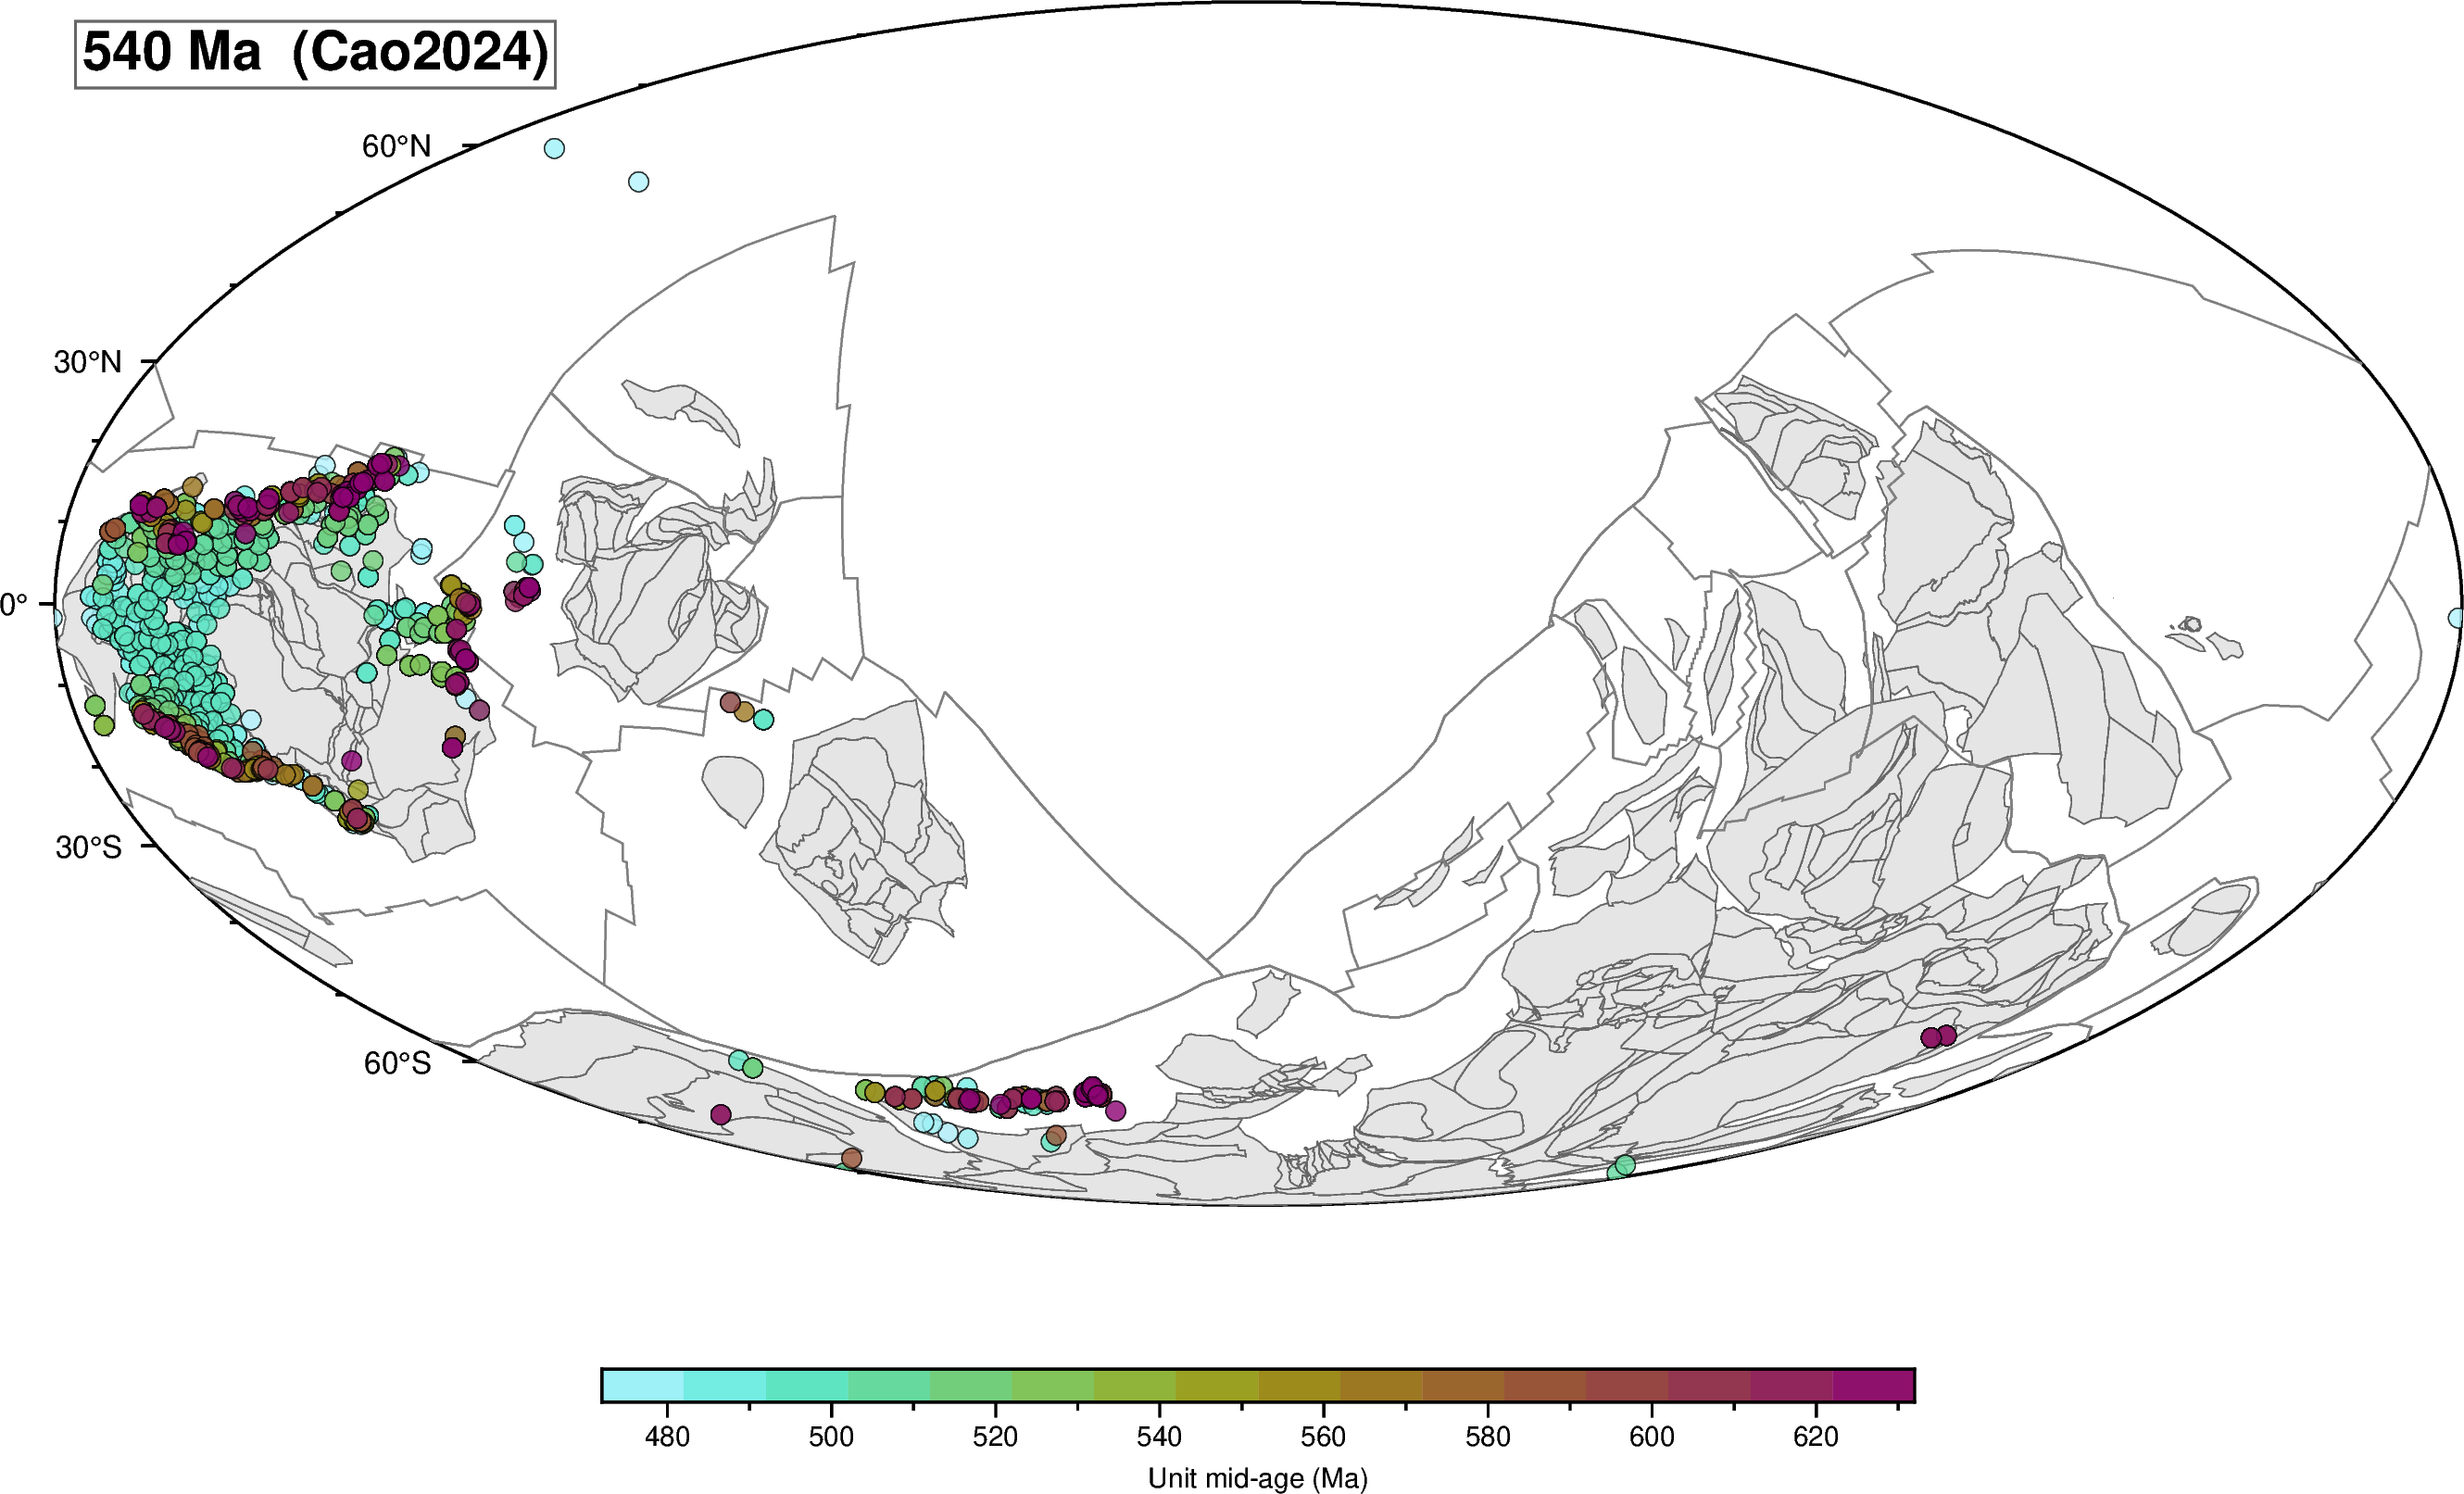

In [10]:
# Cell 4 — render
gplot = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_coastlines(),
    continents=model.get_continental_polygons(),
    COBs=model.get_COBs(),
    time=float(TARGET_TIME))
engine = gplately.PygmtPlotEngine()

fig = pygmt.Figure()
fig.basemap(region="d", projection="W0/22c", frame=["af"])
engine.plot_geo_data_frame(fig, gplot.get_continents(),
                           fill="gray90", pen="0.3p,gray40")
engine.plot_geo_data_frame(fig, gplot.get_all_topological_sections(),
                           pen="0.5p,gray50")

pygmt.makecpt(cmap="hawaii",
              series=[AGE_RANGE_MA[0], AGE_RANGE_MA[1], 10],
              reverse=True)
fig.plot(x=units["paleo_lon"], y=units["paleo_lat"],
         style="c0.18c", fill=units["mid_age"], cmap=True,
         pen="0.25p,black", transparency=20)
fig.colorbar(frame="af+lUnit mid-age (Ma)",
             position="JBC+w12c/0.3c+h+o0/1.5c")

fig.text(text=f"{TARGET_TIME:.0f} Ma  ({MODEL_NAME})",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=1100)
display(HTML('<div style="height:1cm"></div>'))


## What the figure shows

Macrostrat (https://macrostrat.org/) sedimentary-unit centroids at their paleo-positions at `TARGET_TIME` Ma, with each point colour-coded by the unit's mid-age. Older units appear darker / cooler; younger units appear lighter / warmer (the colourbar legend confirms the mapping).

What to read off:

- **Spatial gaps** in the point cloud reveal regions where Macrostrat has no preserved sedimentary record at this age — the Great Unconformity footprint, in particular, shows up as large empty zones over the cratons.
- **Spatial gradients in age colour** reveal sedimentary onlap patterns: at a passive margin one expects to see a fan of progressively younger units offshore. On a craton, the age palette typically reads as broadly uniform within preserved domains.
- **The cluster around active depocentres** (foreland basins, rift shoulders, passive-margin shelves) is the contemporaneous sedimentary record. A scarcity of points around an emerging arc may indicate active uplift rather than missing data.

The reconstruction is the standard `gplately.Points.reconstruct()` at TARGET_TIME for each unit's present-day centroid, so the point density and gaps are inherited from the Macrostrat compilation itself.


## Extend this

- **Sweep the reconstruction age.** Reconstruct each unit to its own mid-age instead of a single common `TARGET_TIME` — i.e. each dot in its own paleo-frame. This is the natural representation of "where was each rock when it formed".
- **Filter by lithology.** Re-run with `lith_class="carbonate"` to highlight tropical-belt carbonates separately from siliciclastics.
- **Other transgressions.** Repoint the age window at the Cretaceous Western Interior Seaway (~94 Ma) and watch the equivalent paleo-distribution.
- **Cross-reference T15.** T15 plots reconstructed metamorphic zircons; T32 plots reconstructed sedimentary units. Together they trace where rocks were formed AND where rocks were deformed in the same reconstruction frame.

## References

- Dhungana, S. & Flament, N. (2025). The deep Earth origin of the Great Unconformity. *JGR — Solid Earth* (in press).
- Peters, S.E. et al. (2018). Macrostrat (https://macrostrat.org/): A platform for geological data integration and deep-time Earth crust research. *Geochem. Geophys. Geosys.* 19, 1393–1409.
- Cao, X. et al. (2024). A deep-time Phanerozoic to Proterozoic plate motion model. *ESSD* 16, 4007–4032.
- Mather, B.R., Müller, R.D., Zahirovic, S., Cannon, J., Chin, M., Ilano, L., Wright, N.M., Alfonso, C., Williams, S., Tetley, M. & Merdith, A. (2024). Deep time spatio-temporal data analysis using GPlately. *Geoscience Data Journal* 11(1), 3–10. https://doi.org/10.1002/gdj3.185
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Tong, J.-H., Ngo, L., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J. & Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.10578540
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems* 20(11), 5556–5564. https://doi.org/10.1029/2019GC008515
- Chin, M., Mather, B.R. & Müller, R.D. (2024). Plate Model Manager: A Python package for downloading and managing plate reconstruction models. *Journal of Open Source Software* 9(101), 7090. https://doi.org/10.21105/joss.07090
